
\usepackage{latexsym,array,amsthm,amssymb,amsfonts,amsmath, mathtools, placeins, cancel}


\section{A Rough Derivation of the Multi-Layer Perceptron}
\textbf{\title{A Rough Derivation of the Multi-Layer Perceptron}} \\
I came across a really exciting theorem: the \textbf{Universal Approximation Theorem}, which states that neural networks can approximate any function to any desired degree of accuracy. I've always enjoyed learning things from the ground up, so before using any modern deep learning frameworks to tackle problems in my field I wanted to build a neural net from scratch. So here goes!... \\

## Derivation \\ 
### 1. General Structure \\
The multi-layer perceptron (MLP) can be visualized as a directed acyclic graph (DAG) composed of vertical layers of nodes, where each node in a given layer is connected to every node in the next layer. The data enters the input layer, flows forward through the hidden layers, and out through the output layer. \\ 
### 2. Forward Propagation and Loss \\
The activation value of a neuron in layer $l$, denoted $a^{[l]}_{i}$, is given by some non-linear activation function, $g^{[l]}(\cdot)$ on the pre-activation value, $z^{[l]}_{i}$, which is given by a weighted sum of the activations in the previous layer plus a bias term, $b^{[l]}_i$. Now consider the activation at the first, $l=0$, and last layer, $l=k-1$, in the network. The activation at the first layer $a^{[0]}_{i}$ is equal to the input $x_i$. The activation at the last layer will depend on the desired behavior of the network; the task at hand is a classification, consequently the softmax activation function will be used for $g^{[k-1]}(\cdot)$ in tandem with the categorical cross-entropy loss function. The softmax function scales the elements of a vector such that they sum to $1$ are and are bounded $\in [0,1]$. This pairing is perfect because the output of softmax will be interpreted as a probability distribution of prediction confidence over the classes and the categorical cross-entropy loss function quantifies the distance between two probability distributions and punishes accordingly. Thus, the general forward pass may be expressed in scalar operations as: \\
$$
\begin{aligned}
a^{[0]}_{i} &= x_{i} \\ 
z^{[l]}_{i} &= \sum_{j}w^{[l]}_{ij}a^{[l-1]}_{j} + b^{[l]}_{i} \\
a^{[l]}_{i} &= g^{[l]}(z^{l}_{i}) \\
a^{[k-1]}_{i} &= \text{softmax}(\mathbf{z}^{[k-1]}) = \frac{\exp({z^{[k-1]}_{i}})}{\sum_{k}{\exp({z^{[k-1]}_{k}})}}\\
\mathcal{L}_{\text{cce}} &= -\sum_{i} y_{i}\text{ln}(a^{[k-1]}_{i})
\end{aligned}
$$ \\

Expressing the neural network as scalar operations is a great intuition builder, but it severely under-leverages modern hardware architecture and libraries such as NumPy which achieve blistering speed by parallelizing vectorized operations. Additionally, modern datasets are often massive and consequently must be to be split into batches for training. Therefore, the notation, implementation, and wall clock performance may be improved by vectorizing the above for $m$ classes with a batch size of $n$ as:
$$
\begin{aligned}
\mathbf{A}^{[0]}&= \mathbf{X} \\
\mathbf{Z}^{[l]} &= \mathbf{W}^{[l]}\mathbf{A}^{[l-1]} + \mathbf{b}^{[l]} \\
\mathbf{A}^{[l]} &= \mathbf{g}^{[l]}(\mathbf{Z}^{[l]}) \\
\mathbf{A}^{[k-1]} &= \text{softmax}(\mathbf{Z}^{[k-1]}) \\
\mathcal{L}_{\text{cce}} &= -\frac{1}{n}\sum^{n}_{j}\sum^{m}_{i} y_{ij}\text{ln}(a^{[k-1]}_{ij})
\end{aligned}
$$

With matrices organized as: \\

$$
\begin{aligned}
    \mathbf{X} &= \begin{pmatrix}
        \uparrow & & \uparrow \\
        \mathbf{x}_1 &\cdots & \mathbf{x}_n \\
        \downarrow & & \downarrow
    \end{pmatrix} \\
    \mathbf{W}^{[l]} &= \begin{pmatrix}
        \leftarrow & \mathbf{w}_1 & \rightarrow \\
        & \vdots & \\
        \leftarrow & \mathbf{w}_\cdot & \rightarrow
    \end{pmatrix} 
\end{aligned}
$$

### 3. Backward Propagation and Gradient Descent \\
At this point, the model can produce predictions and the performance can be quantified, but these predictions are completely random and the model can not learn. The model must change its parameters with respect to the loss function in order to achieve better performance, i.e. learn. \\

A very elegant solution is gradient descent, a calculus-based optimization technique that updates the parameters using the gradient composed of the partial derivatives of the parameters with respect to the loss function. It provides a clean method for determining exactly how much each weight, bias, pre-activation, and activation ripples through the network to affect the loss. Now observe that neural networks may be expressed as composite functions and, subsequently, differentiated using the chain rule (given the composing functions are differentiable). The reader may find it helpful to visualize backpropagation as walking backwards through the network, determining how much each activation, pre-activation, weight, and bias affects the loss. Let: 

$$\theta = \{\mathbf{W}^{[0]},\mathbf{b}^{[0]}, \ldots, \mathbf{W}^{[K-1]},\mathbf{b}^{[K-1]} \}$$

denote the parameter set and

$$
\nabla = \begin{pmatrix}
\frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{W}^{[0]}} & 
\frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{b}^{[0]}} &
\cdots & 
\frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{W}^{[K-1]}} & 
\frac{\partial \mathcal{L}_{\text{cce}}}{\partial \mathbf{b}^{[K-1]}}
\end{pmatrix}^{\top}
$$ 

denote the corresponding gradient. \\

Thus, the parameter set will be updated according to: $\theta_{t+1} = \theta_{t} - \eta \nabla_{t}$, where $\eta$ denotes the learning rate. \\

The first question one might ask when working backwards through the network attributing error is "how does change in some $z^{[K-1]}_j$ affect all $a^{[K-1]}_i$ and how does that affect $\mathcal{L}_{\text{cce}}$?". Posing this question as a derivative: \\
$$
\frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[K-1]}_j} = \sum_i \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a^{[K-1]}_i} \frac{\partial a^{[K-1]}_i}{\partial z^{[K-1]}_j}
$$
As it is clear which derivative is being taken the layer indexing will be dropped to keep the notation cleaner. \\

#### $\frac{\partial \mathcal{L}_{\text{cce}}}{\partial a_i}$ Derivative of the loss with respect to softmax \\
$$
\begin{aligned}
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a_i} &= \frac{\partial}{\partial a_i} \left[- \sum_i y_i \ln(a_i) \right] \\
    &= -\frac{y_i}{a_i}
\end{aligned}
$$

#### $\frac{\partial a_i}{\partial z_j}$ Derivative of softmax with respect to the pre-activation \\
Case 1: $i = j$ \\
$$
\begin{aligned}
    \frac{\partial a_i}{\partial z_i} &= \frac{\partial}{\partial z_i} \left[ \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right] \\
    &= \frac{\frac{\partial}{\partial z_i} \left[\exp(z_i)\right] \sum_k\exp(z_k) - \exp(z_i) \frac{\partial}{\partial z_i} \left[\sum_k\exp(z_k) \right]}{\left( \sum_k \exp(z_k)\right)^2} \qquad \because \text{quotient rule } \\
    &= \frac{\exp(z_i) \sum_k\exp(z_k) - \exp(z_i)\exp(z_i)}{\left( \sum_k \exp(z_k)\right)^2} \\
    &= \left( \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right) \left( \frac{\sum_k \exp(z_k) - \exp(z_i)}{\sum_k \exp(z_k)} \right) \\
    &= \left( \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right) \left( \frac{\sum_k \exp(z_k)}{\sum_k \exp(z_k)} -  \frac{ \exp(z_i)}{\sum_k \exp(z_k)}\right) \\
    &= a_i (1 - a_i)
\end{aligned}
$$

Case 2: $i \ne j$ \\
$$
\begin{aligned}
    \frac{\partial a_i}{\partial z_j} &= \frac{\partial}{\partial z_j} \left[ \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right] \\
    &= \frac{\frac{\partial}{\partial z_j} \left[\exp(z_i)\right] \sum_k\exp(z_k) - \exp(z_i) \frac{\partial}{\partial z_j} \left[\sum_k\exp(z_k) \right]}{\left( \sum_k \exp(z_k)\right)^2} \qquad \because \text{quotient rule } \\
    &= \frac{0(\sum_k \exp(z_k)) - \exp(z_i) \exp(z_j)}{\left( \sum_k \exp(z_k)\right)^2} \\
    &= \frac{- \exp(z_i) \exp(z_j)}{\left( \sum_k \exp(z_k)\right)^2} \\
    &= -\left( \frac{\exp(z_i)}{\sum_k \exp(z_k)} \right)\left( \frac{\exp(z_j)}{\sum_k \exp(z_k)} \right) \\
    &= - a_i a_j
\end{aligned}
$$ 

Now combining the above: \\
$$
\begin{aligned}
    \implies \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z_j} &= \sum_{i \ne j}\left( - \frac{y_i}{a_i} \right)(-a_i a_j) + \left( - \frac{y_j}{a_j} \right)a_j (1 - a_j) \\
    &= \sum_{i \ne j}\frac{y_i a_i a_j}{a_i} + \left( - \frac{y_j a_j (1 - a_j)}{a_j} \right) \\
    &= \sum_{i \ne j} y_i a_j + y_j a_j - y_j \\
    &= \cancelto{1}{\sum_{i \ne j} (y_i + y_j)}a_j - y_j \qquad \because \mathbf{y} \text{ is one-hot encoded} \\
    &= a_j - y_j
\end{aligned} 
$$

Thus, we arrive at a delightfully clean result! \\

Now define the error signal: \\
$$
\delta^{[l]}_i = \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_i}
$$ \\

And observe: \\
$$
\begin{aligned}
    \delta^{[K-1]}_i &= a^{[K-1]}_i - y_i \\
    \implies \mathbf{dZ}^{[K-1]} &= \frac{1}{n} (\mathbf{A}^{[K-1]} - \mathbf{Y}) \qquad \cdot \text{Divide by $n$ to make future computations batch insensitive.} \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial w^{[l]}_{ik}} &= \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_i} \frac{\partial z^{[l]}_i}{\partial w^{[l]}_{ik}} \\
    &=  \delta^{[l]}_i \frac{\partial}{\partial w^{[l]}_{ik}}\left[w^{[l]}_{i1}a^{[l-1]}_1 + \cdots + w^{[l]}_{ik}a^{[l-1]}_k + \cdots + b^{[l]}_i\right] \\
    &= \delta^{[l]}_i a^{[l-1]}_k \\
    \implies \mathbf{dW}^{[l]} &= \mathbf{dZ}^{[l]} (\mathbf{A}^{[l-1]})^{\top} \qquad \because \text{Computing every $ik$ pair is equivalent to an outer product.} \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a^{[l-1]}_{k}} &= \sum_{i} \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_{i}} \frac{\partial z^{[l]}_{i}}{\partial a^{[l-1]}_{k}} \\
    &= \sum_i \delta^{[l]}_i \frac{\partial}{\partial a^{[l]}_{k}}\left[w^{[l]}_{i1}a^{[l-1]}_1 + \cdots + w^{[l]}_{ik}a^{[l-1]}_k + \cdots + b^{[l]}_i\right] \\
    &= \sum_i \delta^{[l]}_i w^{[l]}_{ik} \\
    \implies \mathbf{dA}^{[l-1]} &= (\mathbf{W}^{[l]})^{\top} \mathbf{dZ}^{[l]} \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l-1]}_{k}} &= \frac{\partial \mathcal{L}_{\text{cce}}}{\partial a^{[l-1]}_{k}} \frac{\partial a^{[l-1]}_k}{\partial z^{[l-1]}_{k}} \\
    &= \sum_i \delta^{[l]}_i w^{[l]}_{ik} g^{[l-1]'}(z^{[l-1]}_{k}) \\
    \implies \mathbf{dZ}^{[l-1]} &= ((\mathbf{W}^{[l]})^{\top} \mathbf{dZ}^{[l]}) \mathbf{\odot} \mathbf{g}^{[l-1]'}(\mathbf{Z}^{[l-1]}) \\
    \frac{\partial \mathcal{L}_{\text{cce}}}{\partial b^{[l]}_i} &=  \frac{\partial \mathcal{L}_{\text{cce}}}{\partial z^{[l]}_{i}}  \frac{\partial z^{[l]}_{i}}{\partial b^{[l]}_{i}} \\
    &= \delta^{[l]}_i(1) \\ 
    &= \delta^{[l]}_i \\
    \implies \mathbf{db}^{[l]} &= \sum_n \mathbf{dZ}^{[l]}  
\end{aligned}
$$

    

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [9]:
rng = np.random.default_rng(seed=42)

In [10]:
fp = "mnist.csv"
df = pd.read_csv(fp)
df.reset_index(drop=True, inplace=True)
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [11]:
df = df.T
df

,0,1,2,3,4,5,6,7,8,9,...,41990,41991,41992,41993,41994,41995,41996,41997,41998,41999
label,1,0,1,4,0,0,7,3,5,3,...,3,1,9,6,4,0,1,7,6,9
pixel0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
pixel779,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel780,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel781,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
pixel782,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
df.to_numpy()[0:3, ]

array([[1, 0, 1, ..., 7, 6, 9],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(3, 42000))

In [13]:
ds = df.to_numpy()
ds = rng.permutation(ds, axis=1)        # Perturb matrix columns

assert np.isnan(ds).sum() == 0      # No NaNs!!!

def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

m, n = ds.shape
X_train = normalize(ds[1: ,0:int(0.75*n)])
Y_train = ds[0,0:int(0.75*n)]

X_test = normalize(ds[1: ,int(0.75*n): ])
Y_test = ds[0,int(0.75*n): ]

Y_train_one_hot = np.eye(10)[Y_train].T
Y_test_one_hot = np.eye(10)[Y_test].T


print(X_train.shape, Y_train_one_hot.shape, X_test.shape, Y_test_one_hot.shape)

(784, 31500) (10, 31500) (784, 10500) (10, 10500)


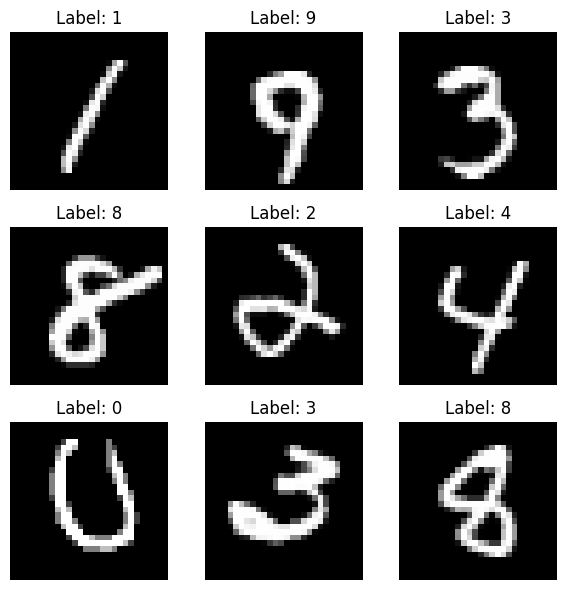

In [14]:
# Create a 3x3 grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()  # Flatten the 2D array of axes for easy looping

for i in range(9):
    # Pick a random index from the training set
    idx = rng.integers(0, X_train.shape[1])
    
    # 1. Reshape the flat 784 pixels back into a 28x28 image
    img = X_train[:,idx].reshape(28, 28)
    
    # 2. Plot the image (cmap='gray' shows it in black and white)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {Y_train[idx]}")
    axes[i].axis('off')  # Hide pixel coordinate axes

plt.tight_layout()
plt.show()


In [15]:
# Define model

def relu(Z):
    return np.maximum(0, Z)     # element-wise

def relu_prime(Z):
    return (Z > 0).astype(int)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def cce(Y_hat, Y):
    eps = 1e-15
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    return -np.mean(np.sum(Y * np.log(Y_hat), axis=0))

def forward(
        X,
        W1, b1,
        W2, b2,
        W3, b3
):
    A0 = X
    
    Z1 = W1 @ A0 + b1
    A1 = relu(Z1)

    Z2 = W2 @ A1 + b2
    A2 = relu(Z2)

    Z3 = W3 @ A2 + b3
    A3 = softmax(Z3)

    return {
        "A3":A3, "Z3":Z3,
        "A2":A2, "Z2":Z2, 
        "A1":A1, "Z1":Z1, 
        "A0":A0,
        "W3":W3, "b3":b3,
        "W2":W2, "b2":b2,
        "W1":W1, "b1":b1
    }


def backward(cache, Y, N):
    A3     = cache["A3"]
    A2, Z2 = cache["A2"], cache["Z2"]
    A1, Z1 = cache["A1"], cache["Z1"]
    A0     = cache["A0"]
    W3     = cache["W3"]
    W2     = cache["W2"]

    dZ3 = (A3 - Y) / N      # make future computations batch insensitive
    dW3 = dZ3 @ A2.T
    db3 = np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = (W3.T @ dZ3) * relu_prime(Z2)
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = (W2.T @ dZ2) * relu_prime(Z1)
    dW1 = dZ1 @ A0.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    return {
        "dW1":dW1, "db1":db1,
        "dW2":dW2, "db2":db2,
        "dW3":dW3, "db3":db3    
    }

In [16]:
# Train!
N = 150     # batch size
ada = 0.1   # learning rate
epochs = 50

loss_history = []
accuracy_history = []

# init weigths and biases
# scale by sqrt(2 / neurons_in)
W1 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 784), size=(64, 784))
b1 = np.zeros((64, 1))

W2 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 64), size=(64, 64))
b2 = np.zeros((64, 1))

W3 = rng.normal(loc=0.0, scale=np.sqrt(2.0 / 64), size=(10, 64))
b3 = np.zeros((10, 1))

for epoch in tqdm(range(epochs)):
    epoch_loss = 0
    correct_predictions = 0
    total_samples = X_train.shape[1]
    
    for i in range(0, X_train.shape[1], N):
        cache = forward(
            X_train[ : ,i:i+N],
            W1, b1,
            W2, b2,
            W3, b3        
        )

        grads = backward(cache, Y_train_one_hot[ : ,i:i+N], N)

        W1 -= ada*grads["dW1"]
        b1 -= ada*grads["db1"]

        W2 -= ada*grads["dW2"]
        b2 -= ada*grads["db2"]

        W3 -= ada*grads["dW3"]
        b3 -= ada*grads["db3"]

    # Metric run
    full_cache = forward(X_train, W1, b1, W2, b2, W3, b3)
    
    # Calculate CCE loss
    current_loss = cce(full_cache["A3"], Y_train_one_hot)
    loss_history.append(current_loss)
    
    # Calculate accuracy 
    predictions = np.argmax(full_cache["A3"], axis=0)
    targets = np.argmax(Y_train_one_hot, axis=0)
    current_accuracy = np.mean(predictions == targets) * 100
    accuracy_history.append(current_accuracy)
    

100%|██████████| 50/50 [00:37<00:00,  1.35it/s]


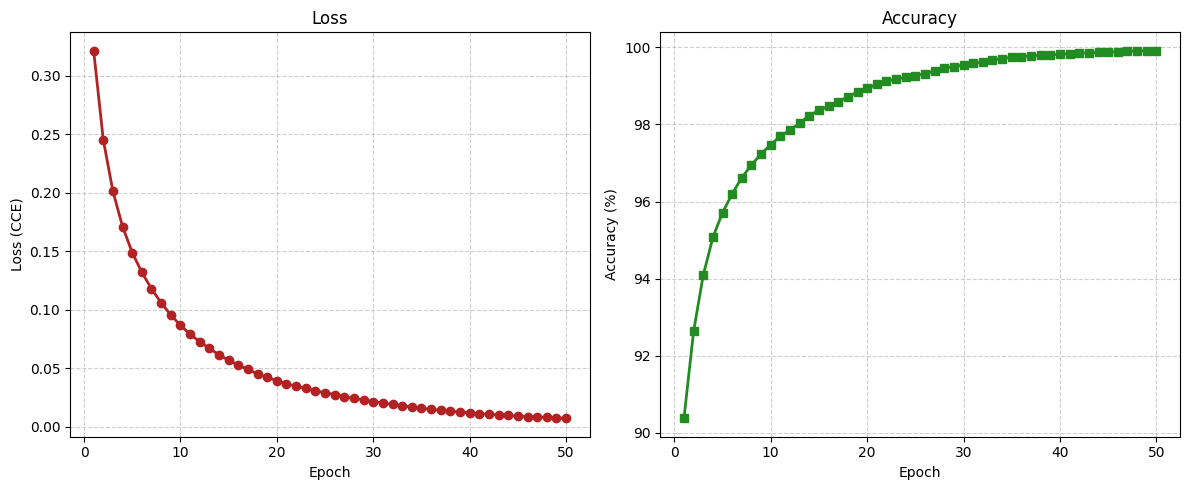

In [17]:
# Plot training performance

plt.figure(figsize=(12, 5))

# Plot CCE Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), loss_history, marker="o", color="firebrick", linewidth=2)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (CCE)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), accuracy_history, marker="s", color="forestgreen", linewidth=2)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
test_cache = forward(X_test, W1, b1, W2, b2, W3, b3)

test_loss = cce(test_cache["A3"], Y_test_one_hot)

predictions = np.argmax(test_cache["A3"], axis=0)
targets = np.argmax(Y_test_one_hot, axis=0)
test_accuracy = np.mean(predictions == targets) * 100
test_accuracy

np.float64(97.01904761904761)